In [37]:
# ─────────────────────────────────────────────────────────────────────────────
#  Core Imports
# ─────────────────────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

# ── Standard Library ──────────────────────────────────────────────────────────
import os
import gc
import pickle
import joblib
from pathlib import Path
from datetime import datetime

# ── Data Manipulation ─────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)

# ── Visualisation ─────────────────────────────────────────────────────────────
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (12, 5), 'font.size': 11})
BRAND_COLOR = "#E63946"   # accent red used consistently throughout

# ── Machine Learning ──────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyRegressor
import xgboost as xgb
import lightgbm as lgb

# ── Explainability ────────────────────────────────────────────────────────────
import shap
shap.initjs()

# ── Statistics ────────────────────────────────────────────────────────────────
from scipy import stats
from scipy.stats import shapiro, mannwhitneyu, kruskal, pearsonr, spearmanr

# ── Interactive Widgets ───────────────────────────────────────────────────────
import ipywidgets as widgets
from IPython.display import display, HTML, Markdown

print(f"✅ All libraries imported successfully")
print(f"   XGBoost  : {xgb.__version__}")
print(f"   LightGBM : {lgb.__version__}")
print(f"   SHAP     : {shap.__version__}")

✅ All libraries imported successfully
   XGBoost  : 3.2.0
   LightGBM : 4.6.0
   SHAP     : 0.52.0


In [38]:
data_dir = './data'
os.makedirs(data_dir, exist_ok=True)


In [39]:

zip_file_path = '/content/rossmann-store-sales.zip'
!unzip -q {zip_file_path} -d {data_dir}

replace ./data/sample_submission.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace ./data/store.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace ./data/test.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace ./data/train.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y


In [40]:
print(f"Files unzipped to: {data_dir}/")
print(os.listdir(data_dir))

Files unzipped to: ./data/
['test.csv', 'train.csv', 'sample_submission.csv', 'store.csv']


In [41]:
df=pd.read_csv('/content/data/train.csv')
df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 9 columns):
 #   Column         Non-Null Count    Dtype 
---  ------         --------------    ----- 
 0   Store          1017209 non-null  int64 
 1   DayOfWeek      1017209 non-null  int64 
 2   Date           1017209 non-null  object
 3   Sales          1017209 non-null  int64 
 4   Customers      1017209 non-null  int64 
 5   Open           1017209 non-null  int64 
 6   Promo          1017209 non-null  int64 
 7   StateHoliday   1017209 non-null  object
 8   SchoolHoliday  1017209 non-null  int64 
dtypes: int64(7), object(2)
memory usage: 69.8+ MB


In [43]:
df_store=pd.read_csv('/content/data/store.csv')
df_store.head()

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0000,9.0000,2008.0000,0,NaN,NaN,NaN
1,2,a,a,570.0000,11.0000,2007.0000,1,13.0000,2010.0000,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0000,12.0000,2006.0000,1,14.0000,2011.0000,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0000,9.0000,2009.0000,0,NaN,NaN,NaN
4,5,a,a,29910.0000,4.0000,2015.0000,0,NaN,NaN,NaN


In [44]:
df_store.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1115 entries, 0 to 1114
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Store                      1115 non-null   int64  
 1   StoreType                  1115 non-null   object 
 2   Assortment                 1115 non-null   object 
 3   CompetitionDistance        1112 non-null   float64
 4   CompetitionOpenSinceMonth  761 non-null    float64
 5   CompetitionOpenSinceYear   761 non-null    float64
 6   Promo2                     1115 non-null   int64  
 7   Promo2SinceWeek            571 non-null    float64
 8   Promo2SinceYear            571 non-null    float64
 9   PromoInterval              571 non-null    object 
dtypes: float64(5), int64(2), object(3)
memory usage: 87.2+ KB


In [45]:
df = df.merge(df_store, on='Store', how='left')
print(f"Merged shape: {df.shape}")

Merged shape: (1017209, 18)


In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 18 columns):
 #   Column                     Non-Null Count    Dtype  
---  ------                     --------------    -----  
 0   Store                      1017209 non-null  int64  
 1   DayOfWeek                  1017209 non-null  int64  
 2   Date                       1017209 non-null  object 
 3   Sales                      1017209 non-null  int64  
 4   Customers                  1017209 non-null  int64  
 5   Open                       1017209 non-null  int64  
 6   Promo                      1017209 non-null  int64  
 7   StateHoliday               1017209 non-null  object 
 8   SchoolHoliday              1017209 non-null  int64  
 9   StoreType                  1017209 non-null  object 
 10  Assortment                 1017209 non-null  object 
 11  CompetitionDistance        1014567 non-null  float64
 12  CompetitionOpenSinceMonth  693861 non-null   float64
 13  CompetitionO

In [47]:
df.isnull().sum()

,0
Store,0
DayOfWeek,0
Date,0
Sales,0
Customers,0
Open,0
Promo,0
StateHoliday,0
SchoolHoliday,0
StoreType,0


In [48]:
def split_date(df):
    df['Date'] = pd.to_datetime(df['Date'])
    df['Year'] = df.Date.dt.year
    df['Month'] = df.Date.dt.month
    df['Day'] = df.Date.dt.day
    df['WeekOfYear'] = df.Date.dt.isocalendar().week

In [49]:
split_date(df)

In [50]:
df.columns

Index(['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo',
       'StateHoliday', 'SchoolHoliday', 'StoreType', 'Assortment',
       'CompetitionDistance', 'CompetitionOpenSinceMonth',
       'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek',
       'Promo2SinceYear', 'PromoInterval', 'Year', 'Month', 'Day',
       'WeekOfYear'],
      dtype='object')

In [51]:
df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,Year,Month,Day,WeekOfYear
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0000,9.0000,2008.0000,0,NaN,NaN,NaN,2015,7,31,31
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0000,11.0000,2007.0000,1,13.0000,2010.0000,"Jan,Apr,Jul,Oct",2015,7,31,31
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0000,12.0000,2006.0000,1,14.0000,2011.0000,"Jan,Apr,Jul,Oct",2015,7,31,31
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0000,9.0000,2009.0000,0,NaN,NaN,NaN,2015,7,31,31
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0000,4.0000,2015.0000,0,NaN,NaN,NaN,2015,7,31,31


In [52]:
df['Open'].value_counts()

,count
Open,
1,844392
0,172817


In [53]:
df_open = df[(df['Open'] == 1) ].copy()
print(f"Open stores with sales > 0 : {len(df_open):,} rows ({len(df_open)/len(df)*100:.1f}%)")

Open stores with sales > 0 : 844,392 rows (83.0%)


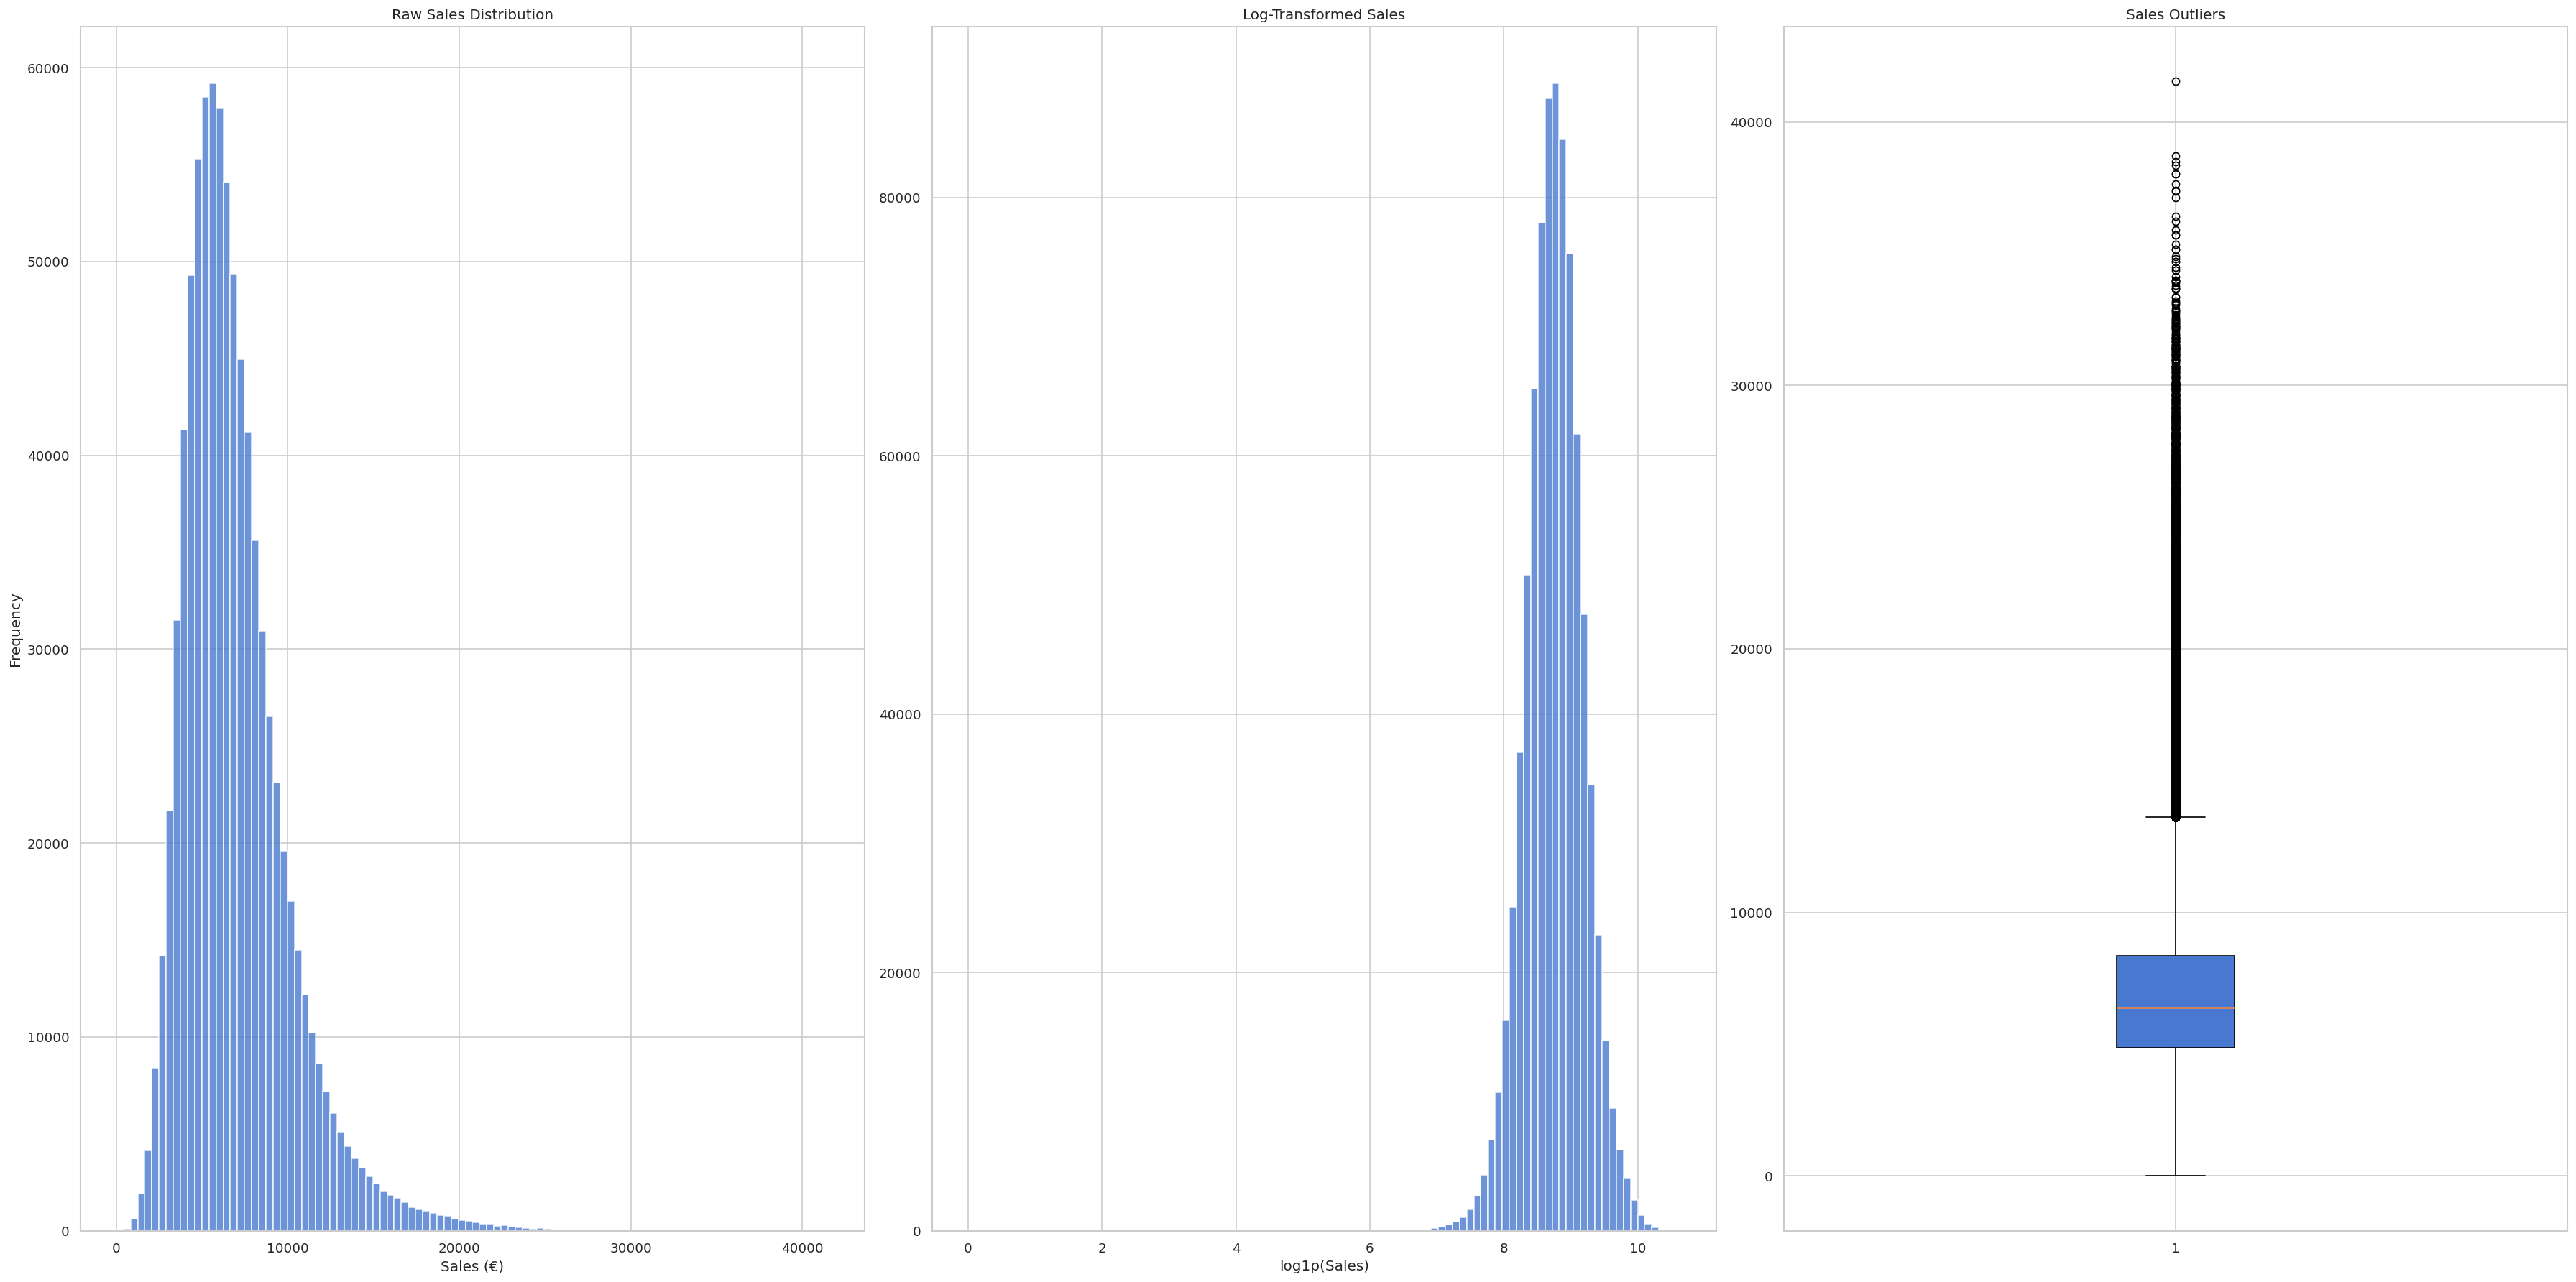

In [54]:
fig, axes = plt.subplots(1, 3, figsize=(30, 15))

# Raw Sales Distribution
axes[0].hist(
    df_open['Sales'],
    bins=100,
    edgecolor='white',
    alpha=0.8
)
axes[0].set_title('Raw Sales Distribution')
axes[0].set_xlabel('Sales (€)')
axes[0].set_ylabel('Frequency')

# Log Distribution
sales_log = np.log1p(df_open['Sales'])

axes[1].hist(
    sales_log,
    bins=100,
    edgecolor='white',
    alpha=0.8
)
axes[1].set_title('Log-Transformed Sales')
axes[1].set_xlabel('log1p(Sales)')

# Boxplot
axes[2].boxplot(
    df_open['Sales'],
    vert=True,
    patch_artist=True
)
axes[2].set_title('Sales Outliers')

plt.tight_layout()
plt.show()

In [55]:
Q1 = df_open['Sales'].quantile(0.25)
Q3 = df_open['Sales'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df_open[
    (df_open['Sales'] < lower) |
    (df_open['Sales'] > upper)
]

print(f"Q1 : {Q1:,.0f}")
print(f"Q3 : {Q3:,.0f}")
print(f"IQR : {IQR:,.0f}")

print(f"Lower Fence : {lower:,.0f}")
print(f"Upper Fence : {upper:,.0f}")

print(f"Outliers : {len(outliers):,}")
print(f"Outlier % : {100*len(outliers)/len(df_open):.2f}%")

Q1 : 4,859
Q3 : 8,360
IQR : 3,501
Lower Fence : -392
Upper Fence : 13,612
Outliers : 30,769
Outlier % : 3.64%


Temporal Sales Trend

In [56]:
# Monthly trend
monthly_sales = (
    df_open.groupby(df_open['Date'].dt.to_period('M'))['Sales']
    .mean()
    .reset_index()
)

# Convert Period to Timestamp for Plotly compatibility
monthly_sales['Date'] = monthly_sales['Date'].dt.to_timestamp()

monthly_sales['Rolling_3M'] = (
    monthly_sales['Sales']
    .rolling(3)
    .mean()
)

fig = px.line(
    monthly_sales,
    x='Date',
    y=['Sales', 'Rolling_3M'],
    title='Monthly Sales Trend with 3-Month Moving Average'
)

fig.show()

In [57]:
dow_sales = (
    df.groupby('DayOfWeek')['Sales']
    .mean()
    .reset_index()
)

dow_labels = {
    1: 'Monday',
    2: 'Tuesday',
    3: 'Wednesday',
    4: 'Thursday',
    5: 'Friday',
    6: 'Saturday',
    7: 'Sunday'
}

dow_sales['Day'] = dow_sales['DayOfWeek'].map(dow_labels)

fig = px.bar(
    dow_sales,
    x='Day',
    y='Sales',
    title='Average Sales by Day of Week',
    color='Sales',
    template='plotly_white'
)

fig.show()

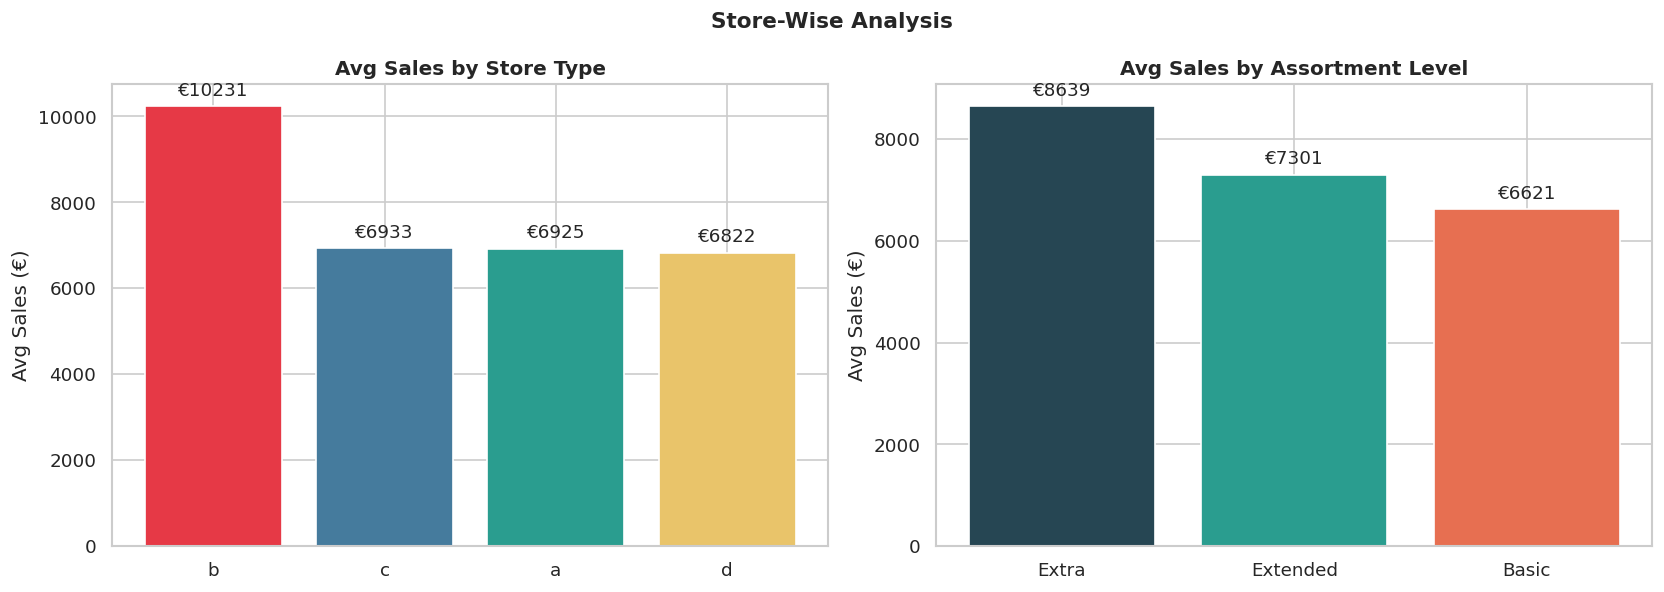


💡 Store Type 'b' has the highest average sales (€10231).
💡 Assortment 'Extra' performs best (€8639).


In [58]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Average Sales by Store Type
stype_sales = (
    df_open.groupby('StoreType')['Sales']
    .mean()
    .sort_values(ascending=False)
)

bars = axes[0].bar(
    stype_sales.index,
    stype_sales.values,
    color=['#E63946', '#457B9D', '#2A9D8F', '#E9C46A']
)

axes[0].bar_label(bars, fmt='€%.0f', padding=4)
axes[0].set_title('Avg Sales by Store Type', fontweight='bold')
axes[0].set_ylabel('Avg Sales (€)')


# Assortment Analysis
assort_map = {'a': 'Basic', 'b': 'Extra', 'c': 'Extended'}

df_temp = df_open.copy()
df_temp['Assortment_Label'] = df_temp['Assortment'].map(assort_map)

assort_sales = (
    df_temp.groupby('Assortment_Label')['Sales']
    .mean()
    .sort_values(ascending=False)
)

bars2 = axes[1].bar(
    assort_sales.index,
    assort_sales.values,
    color=['#264653', '#2A9D8F', '#E76F51']
)

axes[1].bar_label(bars2, fmt='€%.0f', padding=4)
axes[1].set_title('Avg Sales by Assortment Level', fontweight='bold')
axes[1].set_ylabel('Avg Sales (€)')

plt.suptitle('Store-Wise Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(
    f"\n💡 Store Type '{stype_sales.idxmax()}' has the highest average sales "
    f"(€{stype_sales.max():.0f})."
)

print(
    f"💡 Assortment '{assort_sales.idxmax()}' performs best "
    f"(€{assort_sales.max():.0f})."
)

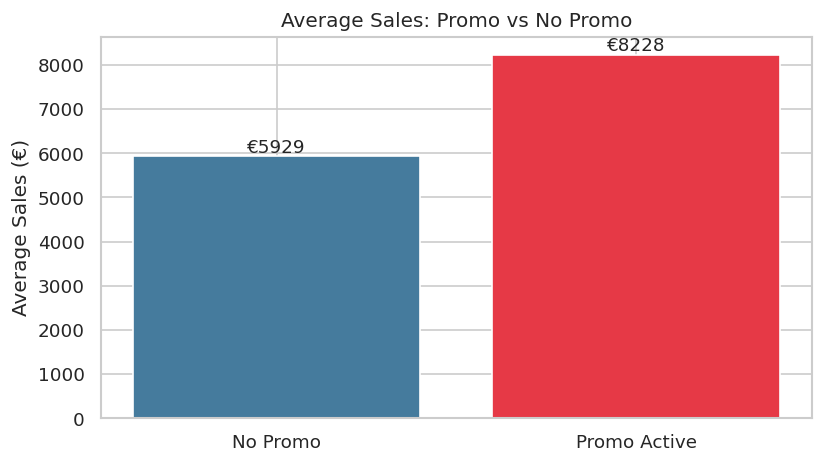


📈 Promotion Sales Lift: +38.8%


In [59]:
promo_sales = df_open.groupby('Promo')['Sales'].mean()

lift = (
    (promo_sales[1] - promo_sales[0])
    / promo_sales[0]
) * 100

fig, ax = plt.subplots(figsize=(7, 4))

bars = ax.bar(
    ['No Promo', 'Promo Active'],
    promo_sales.values,
    color=['#457B9D', BRAND_COLOR]
)

ax.bar_label(bars, fmt='€%.0f')
ax.set_title('Average Sales: Promo vs No Promo')
ax.set_ylabel('Average Sales (€)')

plt.tight_layout()
plt.show()

print(f"\n📈 Promotion Sales Lift: +{lift:.1f}%")

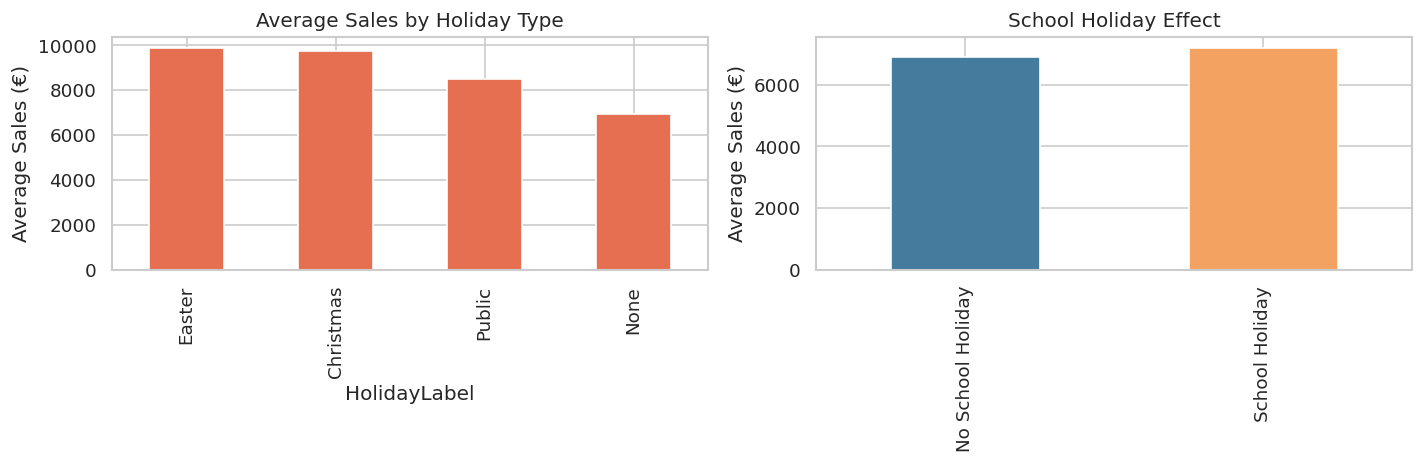


💡 Highest sales holiday type: Easter
💡 School Holiday Sales: €7200


In [60]:

holiday_map = {
    '0': 'None',
    'a': 'Public',
    'b': 'Easter',
    'c': 'Christmas'
}

df_open['HolidayLabel'] = (
    df_open['StateHoliday']
    .astype(str)
    .map(holiday_map)
)

holiday_sales = (
    df_open.groupby('HolidayLabel')['Sales']
    .mean()
    .sort_values(ascending=False)
)

school_sales = (
    df_open.groupby('SchoolHoliday')['Sales']
    .mean()
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# State Holiday Effect
holiday_sales.plot(
    kind='bar',
    ax=axes[0],
    color='#E76F51'
)

axes[0].set_title('Average Sales by Holiday Type')
axes[0].set_ylabel('Average Sales (€)')


# School Holiday Effect
school_sales.index = ['No School Holiday', 'School Holiday']

school_sales.plot(
    kind='bar',
    ax=axes[1],
    color=['#457B9D', '#F4A261']
)

axes[1].set_title('School Holiday Effect')
axes[1].set_ylabel('Average Sales (€)')

plt.tight_layout()
plt.show()

print(
    f"\n💡 Highest sales holiday type: {holiday_sales.idxmax()}"
)

print(
    f"💡 School Holiday Sales: €{school_sales['School Holiday']:.0f}"
)

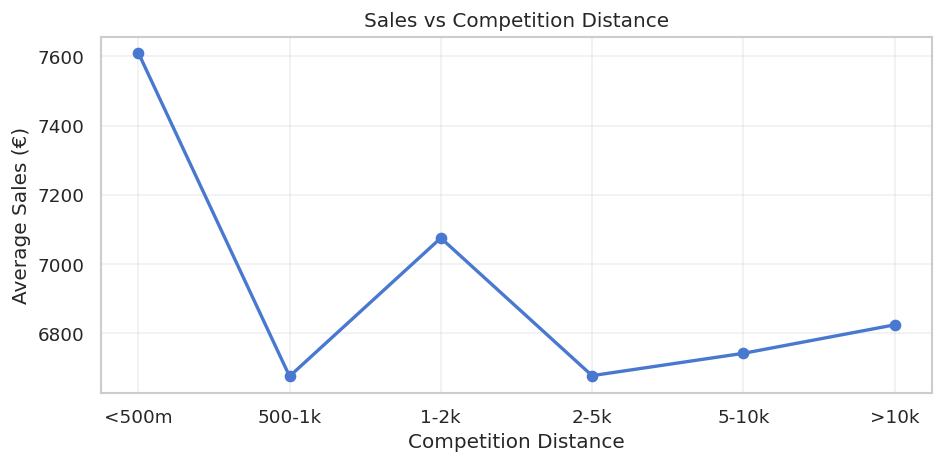


📊 Correlation: -0.036
💡 Strongest sales band: <500m


In [61]:
# ─────────────────────────────────────────────
# Competition Distance Analysis
# ─────────────────────────────────────────────

df_comp = df_open.dropna(subset=['CompetitionDistance'])

bins = [0, 500, 1000, 2000, 5000, 10000, np.inf]
labels = ['<500m', '500-1k', '1-2k', '2-5k', '5-10k', '>10k']

df_comp['DistanceBand'] = pd.cut(
    df_comp['CompetitionDistance'],
    bins=bins,
    labels=labels
)

comp_sales = (
    df_comp.groupby('DistanceBand', observed=True)['Sales']
    .mean()
)

plt.figure(figsize=(8,4))

plt.plot(
    comp_sales.index,
    comp_sales.values,
    marker='o',
    linewidth=2
)

plt.title('Sales vs Competition Distance')
plt.xlabel('Competition Distance')
plt.ylabel('Average Sales (€)')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

corr = df_comp['CompetitionDistance'].corr(df_comp['Sales'])

print(f"\n📊 Correlation: {corr:.3f}")
print(f"💡 Strongest sales band: {comp_sales.idxmax()}")

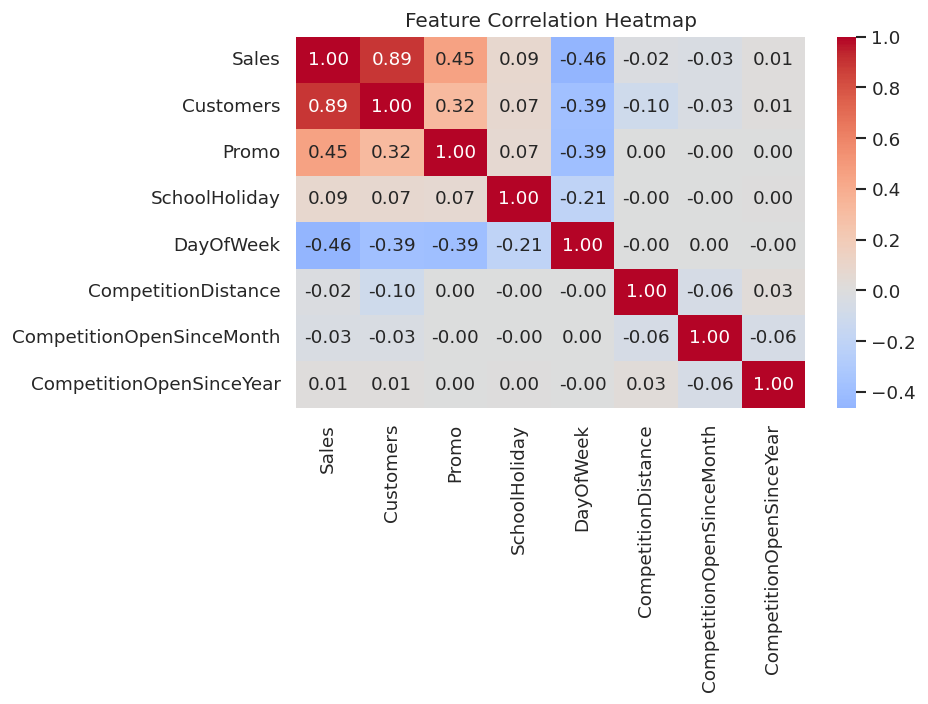


💡 Strongest predictor: Customers
💡 Correlation with Sales: 0.89


In [62]:
# ─────────────────────────────────────────────
# Correlation Heatmap
# ─────────────────────────────────────────────

num_cols = [
    'Sales',
    'Customers',
    'Promo',
    'SchoolHoliday',
    'DayOfWeek',
    'CompetitionDistance',
    'CompetitionOpenSinceMonth',
    'CompetitionOpenSinceYear'
]

corr_matrix = df[num_cols].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)

plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

sales_corr = corr_matrix['Sales'].drop('Sales').abs().sort_values(ascending=False)

print(f"\n💡 Strongest predictor: {sales_corr.index[0]}")
print(f"💡 Correlation with Sales: {sales_corr.iloc[0]:.2f}")

In [63]:
# =============================================================================
# HYPOTHESIS TESTING & A/B ANALYSIS
# =============================================================================

from scipy.stats import mannwhitneyu, kruskal

print("="*60)
print("PROMOTION A/B TEST")
print("="*60)

# Group A = No Promotion
no_promo = df_open[df_open['Promo'] == 0]['Sales']

# Group B = Promotion Active
promo = df_open[df_open['Promo'] == 1]['Sales']

# Sales Lift
lift = (
    (promo.mean() - no_promo.mean())
    / no_promo.mean()
) * 100

# Mann-Whitney U Test
stat, p_value = mannwhitneyu(
    promo,
    no_promo,
    alternative='greater'
)

print(f"Average Sales (No Promo) : €{no_promo.mean():,.2f}")
print(f"Average Sales (Promo)    : €{promo.mean():,.2f}")
print(f"Sales Lift              : {lift:.2f}%")
print(f"P-value                 : {p_value:.8f}")

if p_value < 0.05:
    print("✅ Promotions significantly increase sales.")
else:
    print("❌ No statistically significant impact detected.")


print("\n" + "="*60)
print("STORE TYPE HYPOTHESIS TEST")
print("="*60)

groups = [
    df_open[df_open['StoreType'] == st]['Sales']
    for st in sorted(df_open['StoreType'].unique())
]

stat, p_value = kruskal(*groups)

print(f"P-value : {p_value:.8f}")

if p_value < 0.05:
    print("✅ Store types have significantly different sales distributions.")
else:
    print("❌ No significant difference between store types.")


print("\n" + "="*60)
print("SCHOOL HOLIDAY TEST")
print("="*60)

holiday = df_open[df_open['SchoolHoliday'] == 1]['Sales']
normal = df_open[df_open['SchoolHoliday'] == 0]['Sales']

stat, p_value = mannwhitneyu(
    holiday,
    normal,
    alternative='two-sided'
)

print(f"Holiday Avg Sales : €{holiday.mean():,.2f}")
print(f"Normal Avg Sales  : €{normal.mean():,.2f}")
print(f"P-value           : {p_value:.8f}")

if p_value < 0.05:
    print("✅ School holidays significantly affect sales.")
else:
    print("❌ School holidays do not significantly affect sales.")

PROMOTION A/B TEST
Average Sales (No Promo) : €5,929.41
Average Sales (Promo)    : €8,228.28
Sales Lift              : 38.77%
P-value                 : 0.00000000
✅ Promotions significantly increase sales.

STORE TYPE HYPOTHESIS TEST
P-value : 0.00000000
✅ Store types have significantly different sales distributions.

SCHOOL HOLIDAY TEST
Holiday Avg Sales : €7,200.18
Normal Avg Sales  : €6,896.78
P-value           : 0.00000000
✅ School holidays significantly affect sales.


# Feature Engineering

In [84]:
import numpy as np
import pandas as pd

# =====================================================
# DATE FEATURES
# =====================================================
df['Date'] = pd.to_datetime(df['Date'])

df['Year']        = df['Date'].dt.year
df['Month']       = df['Date'].dt.month
df['Day']         = df['Date'].dt.day
df['Quarter']     = df['Date'].dt.quarter
df['WeekOfYear']  = df['Date'].dt.isocalendar().week.astype(int)
df['DayOfYear']   = df['Date'].dt.dayofyear
df['DayOfWeek']   = df['Date'].dt.dayofweek + 1

df['IsWeekend']    = (df['DayOfWeek'] >= 6).astype(int)
df['IsMonthStart'] = df['Date'].dt.is_month_start.astype(int)
df['IsMonthEnd']   = df['Date'].dt.is_month_end.astype(int)
df['IsQuarterEnd'] = df['Date'].dt.is_quarter_end.astype(int)
df['IsYearEnd']    = df['Date'].dt.is_year_end.astype(int)

# Cyclical encoding
df['Month_sin'] = np.sin(2 * np.pi * df['Month'] / 12)
df['Month_cos'] = np.cos(2 * np.pi * df['Month'] / 12)

df['Dow_sin'] = np.sin(2 * np.pi * df['DayOfWeek'] / 7)
df['Dow_cos'] = np.cos(2 * np.pi * df['DayOfWeek'] / 7)

# =====================================================
# MISSING VALUES
# =====================================================
df['CompetitionDistance'] = (
    df['CompetitionDistance']
    .fillna(df['CompetitionDistance'].median())
)

fill_zero_cols = [
    'CompetitionOpenSinceMonth',
    'CompetitionOpenSinceYear',
    'Promo2SinceWeek',
    'Promo2SinceYear'
]

for col in fill_zero_cols:
    df[col] = df[col].fillna(0).astype(int)

df['PromoInterval'] = df['PromoInterval'].fillna('None')

# =====================================================
# COMPETITION FEATURES
# =====================================================
comp_date = pd.to_datetime(
    dict(
        year=df['CompetitionOpenSinceYear'].replace(0, np.nan),
        month=df['CompetitionOpenSinceMonth'].replace(0, np.nan),
        day=1
    ),
    errors='coerce'
)

df['CompetitionOpenMonths'] = (
    ((df['Date'] - comp_date).dt.days / 30)
    .fillna(0)
    .clip(lower=0)
)

df['CompetitionOpenDays'] = (
    (df['Date'] - comp_date)
    .dt.days
    .fillna(0)
    .clip(lower=0)
)

# =====================================================
# PROMO2 FEATURES
# =====================================================
month_map = {
    1:'Jan', 2:'Feb', 3:'Mar', 4:'Apr',
    5:'May', 6:'Jun', 7:'Jul', 8:'Aug',
    9:'Sept', 10:'Oct', 11:'Nov', 12:'Dec'
}

df['MonthStr'] = df['Month'].map(month_map)

def promo2_active(row):
    if row['Promo2'] == 0:
        return 0

    months = str(row['PromoInterval']).split(',')

    return int(row['MonthStr'] in months)

df['Promo2Active'] = df.apply(promo2_active, axis=1)

df.drop(columns=['MonthStr'], inplace=True)

# =====================================================
# STORE HISTORY FEATURES
# =====================================================
df = df.sort_values(['Store', 'Date'])
import numpy as np
import pandas as pd

# =====================================================
# DATE FEATURES
# =====================================================
df['Date'] = pd.to_datetime(df['Date'])

df['Year']        = df['Date'].dt.year
df['Month']       = df['Date'].dt.month
df['Day']         = df['Date'].dt.day
df['Quarter']     = df['Date'].dt.quarter
df['WeekOfYear']  = df['Date'].dt.isocalendar().week.astype(int)
df['DayOfYear']   = df['Date'].dt.dayofyear
df['DayOfWeek']   = df['Date'].dt.dayofweek + 1

df['IsWeekend']    = (df['DayOfWeek'] >= 6).astype(int)
df['IsMonthStart'] = df['Date'].dt.is_month_start.astype(int)
df['IsMonthEnd']   = df['Date'].dt.is_month_end.astype(int)
df['IsQuarterEnd'] = df['Date'].dt.is_quarter_end.astype(int)
df['IsYearEnd']    = df['Date'].dt.is_year_end.astype(int)

# Cyclical encoding
df['Month_sin'] = np.sin(2 * np.pi * df['Month'] / 12)
df['Month_cos'] = np.cos(2 * np.pi * df['Month'] / 12)

df['Dow_sin'] = np.sin(2 * np.pi * df['DayOfWeek'] / 7)
df['Dow_cos'] = np.cos(2 * np.pi * df['DayOfWeek'] / 7)

# =====================================================
# MISSING VALUES
# =====================================================
df['CompetitionDistance'] = (
    df['CompetitionDistance']
    .fillna(df['CompetitionDistance'].median())
)

fill_zero_cols = [
    'CompetitionOpenSinceMonth',
    'CompetitionOpenSinceYear',
    'Promo2SinceWeek',
    'Promo2SinceYear'
]

for col in fill_zero_cols:
    df[col] = df[col].fillna(0).astype(int)

df['PromoInterval'] = df['PromoInterval'].fillna('None')

# =====================================================
# COMPETITION FEATURES
# =====================================================
comp_date = pd.to_datetime(
    dict(
        year=df['CompetitionOpenSinceYear'].replace(0, np.nan),
        month=df['CompetitionOpenSinceMonth'].replace(0, np.nan),
        day=1
    ),
    errors='coerce'
)

df['CompetitionOpenMonths'] = (
    ((df['Date'] - comp_date).dt.days / 30)
    .fillna(0)
    .clip(lower=0)
)

df['CompetitionOpenDays'] = (
    (df['Date'] - comp_date)
    .dt.days
    .fillna(0)
    .clip(lower=0)
)

# =====================================================
# PROMO2 FEATURES
# =====================================================
month_map = {
    1:'Jan', 2:'Feb', 3:'Mar', 4:'Apr',
    5:'May', 6:'Jun', 7:'Jul', 8:'Aug',
    9:'Sept', 10:'Oct', 11:'Nov', 12:'Dec'
}

df['MonthStr'] = df['Month'].map(month_map)

def promo2_active(row):
    if row['Promo2'] == 0:
        return 0

    months = str(row['PromoInterval']).split(',')

    return int(row['MonthStr'] in months)

df['Promo2Active'] = df.apply(promo2_active, axis=1)

df.drop(columns=['MonthStr'], inplace=True)

# =====================================================
# STORE HISTORY FEATURES
# =====================================================
df = df.sort_values(['Store', 'Date'])

# Open but zero sales
df['UnusualClosure'] = (
    (df['Open'] == 1) &
    (df['Sales'] == 0)
).astype(int)

# Consecutive closed days
closed = (df['Open'] == 0).astype(int)

df['ConsecClosed'] = (
    closed.groupby(df['Store'])
    .transform(
        lambda x:
        x.groupby((x == 0).cumsum()).cumsum()
    )
)

# =====================================================
# INTERACTION FEATURES
# =====================================================
df['Promo_DayOfWeek'] = (
    df['Promo'] * df['DayOfWeek']
)

df['Promo_Competition'] = (
    df['Promo'] * df['CompetitionDistance']
)

# =====================================================
# TARGET TRANSFORM
# =====================================================
if 'Sales' in df.columns:
    df['LogSales'] = np.log1p(df['Sales'])

# =====================================================
# CATEGORICAL ENCODING
# =====================================================
if 'StateHoliday' in df.columns:
    df['StateHoliday'] = df['StateHoliday'].astype(str)

categorical_cols = [
    c for c in [
        'StoreType',
        'Assortment',
        'StateHoliday'
    ]
    if c in df.columns
]

df = pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first=False,
    dtype=np.int8
)

df = df.loc[:, ~df.columns.duplicated()]

print(f"Null values remaining: {df.isnull().sum().sum():,}")
print(f"Final shape: {df.shape}")

# Open but zero sales
df['UnusualClosure'] = (
    (df['Open'] == 1) &
    (df['Sales'] == 0)
).astype(int)

# Consecutive closed days
closed = (df['Open'] == 0).astype(int)

df['ConsecClosed'] = (
    closed.groupby(df['Store'])
    .transform(
        lambda x:
        x.groupby((x == 0).cumsum()).cumsum()
    )
)

# =====================================================
# INTERACTION FEATURES
# =====================================================
df['Promo_DayOfWeek'] = (
    df['Promo'] * df['DayOfWeek']
)

df['Promo_Competition'] = (
    df['Promo'] * df['CompetitionDistance']
)

# =====================================================
# TARGET TRANSFORM
# =====================================================
if 'Sales' in df.columns:
    df['LogSales'] = np.log1p(df['Sales'])

# =====================================================
# CATEGORICAL ENCODING
# =====================================================
if 'StateHoliday' in df.columns:
    df['StateHoliday'] = df['StateHoliday'].astype(str)

categorical_cols = [
    c for c in [
        'StoreType',
        'Assortment',
        'StateHoliday'
    ]
    if c in df.columns
]

df = pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first=False,
    dtype=np.int8
)

df = df.loc[:, ~df.columns.duplicated()]

print(f"Null values remaining: {df.isnull().sum().sum():,}")
print(f"Final shape: {df.shape}")

Null values remaining: 140,334
Final shape: (1017209, 53)
Null values remaining: 140,334
Final shape: (1017209, 53)


In [85]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1017209 entries, 1016095 to 1114
Data columns (total 53 columns):
 #   Column                     Non-Null Count    Dtype         
---  ------                     --------------    -----         
 0   Store                      1017209 non-null  int64         
 1   DayOfWeek                  1017209 non-null  int32         
 2   Date                       1017209 non-null  datetime64[ns]
 3   Sales                      1017209 non-null  int64         
 4   Customers                  1017209 non-null  int64         
 5   Open                       1017209 non-null  int64         
 6   Promo                      1017209 non-null  int64         
 7   SchoolHoliday              1017209 non-null  int64         
 8   CompetitionDistance        1017209 non-null  float64       
 9   CompetitionOpenSinceMonth  1017209 non-null  int64         
 10  CompetitionOpenSinceYear   1017209 non-null  int64         
 11  Promo2                     1017209 non-

In [86]:
def rmspe(y_true, y_pred):
    """Root Mean Squared Percentage Error — lower is better."""
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0
    pct_err = (y_true[mask] - y_pred[mask]) / y_true[mask]
    return np.sqrt(np.mean(pct_err ** 2))


def rmspe_lgb(y_true, y_pred):
    """LightGBM custom eval callback for RMSPE (on log scale targets)."""
    # y_true is already the true labels, no need for dataset.get_label()
    # convert log-scale back to raw sales for true RMSPE
    y_true_sales  = np.expm1(y_true)
    y_pred_sales  = np.expm1(y_pred)
    score = rmspe(y_true_sales, y_pred_sales)
    return 'rmspe', score, False   # False = lower is better

In [87]:
df.info

<bound method DataFrame.info of          Store  DayOfWeek       Date  Sales  Customers  Open  Promo  \
1016095      1          2 2013-01-01      0          0     0      0   
1014980      1          3 2013-01-02   5530        668     1      0   
1013865      1          4 2013-01-03   4327        578     1      0   
1012750      1          5 2013-01-04   4486        619     1      0   
1011635      1          6 2013-01-05   4997        635     1      0   
...        ...        ...        ...    ...        ...   ...    ...   
5574      1115          1 2015-07-27  10712        608     1      1   
4459      1115          2 2015-07-28   8093        500     1      1   
3344      1115          3 2015-07-29   7661        473     1      1   
2229      1115          4 2015-07-30   8405        502     1      1   
1114      1115          5 2015-07-31   8680        538     1      1   

         SchoolHoliday  CompetitionDistance  CompetitionOpenSinceMonth  \
1016095              1            1270.0000                          9   
1014980              1            1270.0000                          9   
1013865              1            1270.0000                          9   
1012750              1            1270.0000                          9   
1011635              1            1270.0000                          9   
...                ...                  ...                        ...   
5574                 1            5350.0000                          0   
4459                 1            5350.0000                          0   
3344                 1            5350.0000                          0   
2229                 1            5350.0000                          0   
1114                 1            5350.0000                          0   

         CompetitionOpenSinceYear  Promo2  Promo2SinceWeek  Promo2SinceYear  \
1016095                      2008       0                0                0   
1014980                      2008       0                0                0   
1013865                      2008       0                0                0   
1012750                      2008       0                0                0   
1011635                      2008       0                0                0   
...                           ...     ...              ...              ...   
5574                            0       1               22             2012   
4459                            0       1               22             2012   
3344                            0       1               22             2012   
2229                            0       1               22             2012   
1114                            0       1               22             2012   

            PromoInterval  Year  Month  Day  WeekOfYear  Quarter  \
1016095              None  2013      1    1           1        1   
1014980              None  2013      1    2           1        1   
1013865              None  2013      1    3           1        1   
1012750              None  2013      1    4           1        1   
1011635              None  2013      1    5           1        1   
...                   ...   ...    ...  ...         ...      ...   
5574     Mar,Jun,Sept,Dec  2015      7   27          31        3   
4459     Mar,Jun,Sept,Dec  2015      7   28          31        3   
3344     Mar,Jun,Sept,Dec  2015      7   29          31        3   
2229     Mar,Jun,Sept,Dec  2015      7   30          31        3   
1114     Mar,Jun,Sept,Dec  2015      7   31          31        3   

         CompetitionOpen  Promo2Active  LogSales  StoreType_a  StoreType_b  \
1016095               52             0    0.0000        False        False   
1014980               52             0    8.6181        False        False   
1013865               52             0    8.3729        False        False   
1012750               52             0    8.4089        False        False   
1011635               52             0    8.5168        False        F

In [88]:
# =============================================================================
# MODEL PREPARATION
# =============================================================================

drop_cols = [
    'Date',
    'Sales',      # target
    'PromoInterval', # Remove object type column
    'LogSales',
    'Customers'
]

X = df.drop(columns=drop_cols)
y = df['LogSales']

print("Feature Matrix Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Matrix Shape: (1017209, 48)
Target Shape: (1017209,)


In [89]:
# Sort by date
df = df.sort_values('Date')

split_date = '2015-06-15'

train_df = df[df['Date'] < split_date]
valid_df = df[df['Date'] >= split_date]

X_train = train_df.drop(columns=drop_cols)
y_train = train_df['LogSales']

X_valid = valid_df.drop(columns=drop_cols)
y_valid = valid_df['LogSales']

print("Train:", X_train.shape)
print("Valid:", X_valid.shape)

Train: (964804, 48)
Valid: (52405, 48)


In [90]:
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error

baseline = DummyRegressor(strategy='mean')
baseline.fit(X_train, y_train)

preds = baseline.predict(X_valid)

mae = mean_absolute_error(y_valid, preds)

print(f"Baseline MAE: {mae:.4f}")

Baseline MAE: 2.2566


In [91]:
import lightgbm as lgb

lgb_model = lgb.LGBMRegressor(
    n_estimators=3000,
    learning_rate=0.02,
    num_leaves=127,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

lgb_model.fit(
    X_train,
    y_train,
    eval_set=[(X_valid, y_valid)], # Evaluate on the validation set
    eval_metric=rmspe_lgb,        # Use custom RMSPE metric
    callbacks=[ lgb.early_stopping(200, verbose=True),
        lgb.log_evaluation(period=200),] # Early stopping to prevent overfitting
)

preds_log   = lgb_model.predict(X_valid, num_iteration=lgb_model.best_iteration_)
preds_sales = np.expm1(preds_log)
actual_sales = np.expm1(y_valid)

mae       = mean_absolute_error(actual_sales, preds_sales)
rmspe_val = rmspe(actual_sales, preds_sales)         # Kaggle metric

print(f"LightGBM MAE   : {mae:.2f}")
print(f"LightGBM RMSPE : {rmspe_val:.5f}")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.175885 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2875
[LightGBM] [Info] Number of data points in the train set: 964804, number of used features: 48
[LightGBM] [Info] Start training from score 7.246525
Training until validation scores don't improve for 200 rounds
[200]	valid_0's l2: 0.019187	valid_0's rmspe: 0.141947
[400]	valid_0's l2: 0.0148711	valid_0's rmspe: 0.137424
[600]	valid_0's l2: 0.014148	valid_0's rmspe: 0.133949
[800]	valid_0's l2: 0.0137463	valid_0's rmspe: 0.131913
[1000]	valid_0's l2: 0.0134892	valid_0's rmspe: 0.130445
[1200]	valid_0's l2: 0.0133661	valid_0's rmspe: 0.129795
[1400]	valid_0's l2: 0.0132188	valid_0's rmspe: 0.12909
[1600]	valid_0's l2: 0.0131029	valid_0's rmspe: 0.128516
[1800]	valid_0's l2: 0.0129876	valid_0's rmspe: 0.127938
[2000]	valid_0's l2: 0.01

In [92]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Predictions on log scale
pred_log = lgb_model.predict(X_valid)

# Convert back to sales
pred_sales = np.expm1(pred_log)
actual_sales = np.expm1(y_valid)

mae = mean_absolute_error(actual_sales, pred_sales)
rmse = np.sqrt(mean_squared_error(actual_sales, pred_sales))
r2 = r2_score(actual_sales, pred_sales)

print("="*50)
print("LIGHTGBM PERFORMANCE")
print("="*50)
print(f"MAE  : {mae:,.2f}")
print(f"RMSE : {rmse:,.2f}")
print(f"R²   : {r2:.4f}")
print(f"LightGBM RMSPE : {rmspe_val:.5f}")

LIGHTGBM PERFORMANCE
MAE  : 555.76
RMSE : 860.76
R²   : 0.9468
LightGBM RMSPE : 0.12613


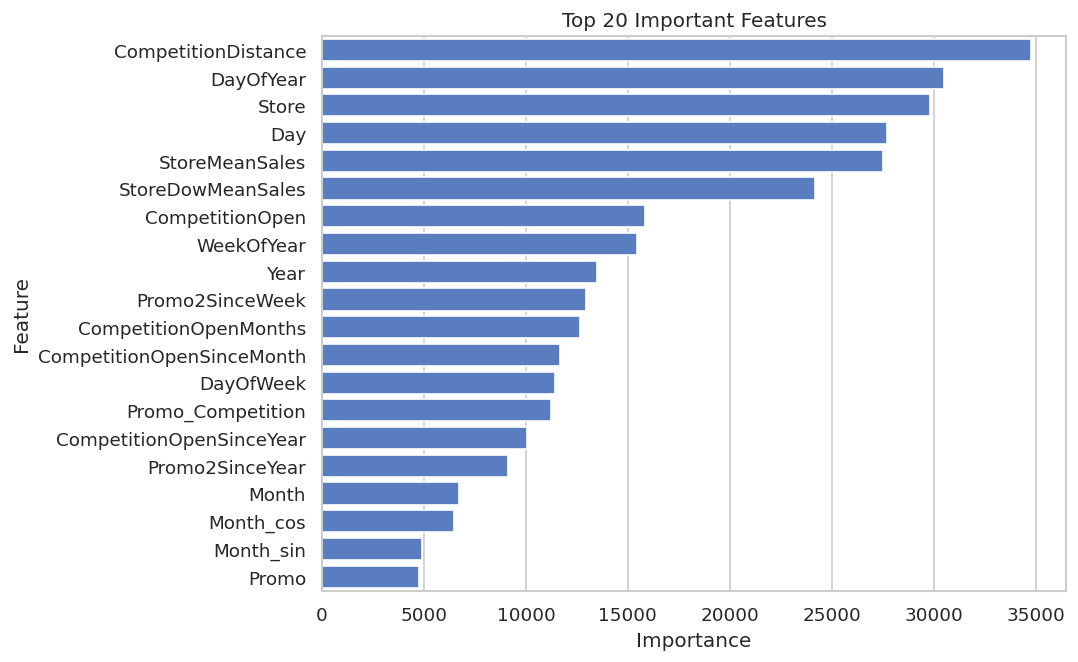

In [93]:
importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': lgb_model.feature_importances_
})

importance = importance.sort_values(
    'Importance',
    ascending=False
).head(20)

plt.figure(figsize=(8,6))

sns.barplot(
    data=importance,
    x='Importance',
    y='Feature'
)

plt.title("Top 20 Important Features")
plt.show()

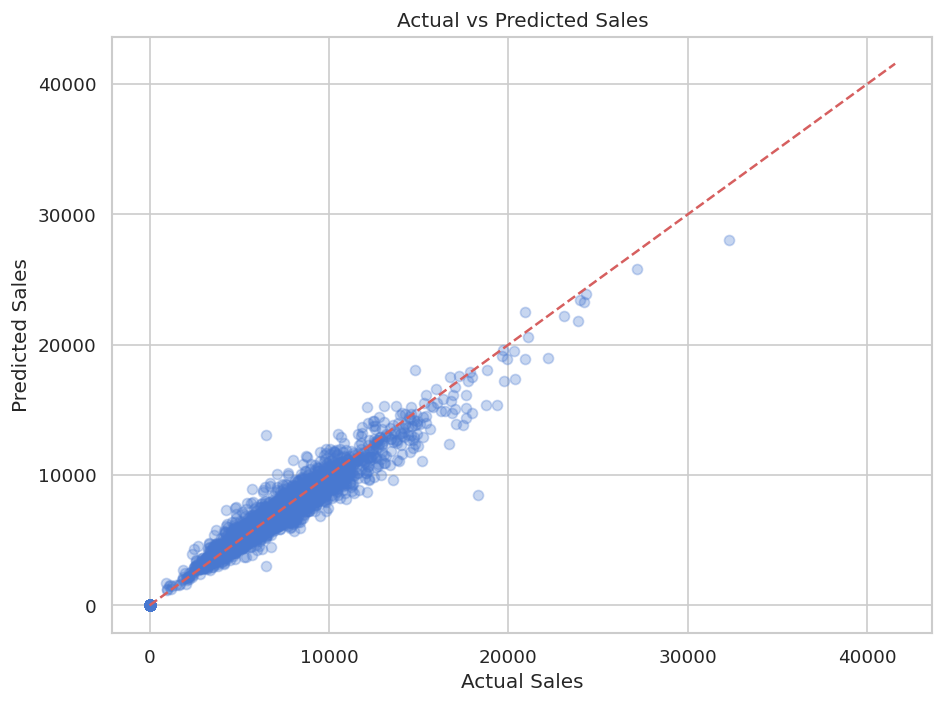

In [94]:
sample_idx = np.random.choice(
    len(actual_sales),
    3000,
    replace=False
)

plt.figure(figsize=(8,6))

plt.scatter(
    actual_sales.iloc[sample_idx],
    pred_sales[sample_idx],
    alpha=0.3
)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")

lims = [
    min(actual_sales.min(), pred_sales.min()),
    max(actual_sales.max(), pred_sales.max())
]

plt.plot(lims, lims, 'r--')
plt.tight_layout()
plt.show()

In [95]:
xgb_model = xgb.XGBRegressor(
    objective         = 'reg:squarederror',
    n_estimators      = 5000,
    learning_rate     = 0.01,
    max_depth         = 10,
    min_child_weight  = 20,
    subsample         = 0.8,
    colsample_bytree  = 0.7,
    random_state      = 42,
    n_jobs            = -1,
    early_stopping_rounds = 200,
)

xgb_model.fit(
    X_train, y_train,
    eval_set = [(X_valid, y_valid)],
    verbose  = 200
)

# FIX — use best_iteration so you don't predict with extra trees
xgb_pred_log = xgb_model.predict(
    X_valid,
    iteration_range=(0, xgb_model.best_iteration + 1)  # ← only change
)

xgb_pred = np.expm1(xgb_pred_log)
xgb_pred = np.clip(xgb_pred, 0, None)

mae       = mean_absolute_error(actual_sales, xgb_pred)
rmse      = np.sqrt(mean_squared_error(actual_sales, xgb_pred))
r2        = r2_score(actual_sales, xgb_pred)
rmspe_val = rmspe(actual_sales, xgb_pred)

print("\n" + "="*60)
print("XGBOOST PERFORMANCE")
print("="*60)
print(f"Best Iteration : {xgb_model.best_iteration}")
print(f"Best Score     : {xgb_model.best_score:.5f}  (log-scale RMSE)")
print(f"\nRMSPE : {rmspe_val:.5f}  ← Kaggle metric")
print(f"MAE   : {mae:,.2f}")
print(f"RMSE  : {rmse:,.2f}")
print(f"R²    : {r2:.4f}")
print("="*60)

[0]	validation_0-rmse:2.93677
[200]	validation_0-rmse:0.41940
[400]	validation_0-rmse:0.13708
[600]	validation_0-rmse:0.12248
[800]	validation_0-rmse:0.11932
[1000]	validation_0-rmse:0.11648
[1200]	validation_0-rmse:0.11469
[1400]	validation_0-rmse:0.11349
[1600]	validation_0-rmse:0.11266
[1800]	validation_0-rmse:0.11205
[2000]	validation_0-rmse:0.11154
[2200]	validation_0-rmse:0.11115
[2400]	validation_0-rmse:0.11079
[2600]	validation_0-rmse:0.11047
[2800]	validation_0-rmse:0.11028
[3000]	validation_0-rmse:0.11009
[3200]	validation_0-rmse:0.10991
[3400]	validation_0-rmse:0.10975
[3600]	validation_0-rmse:0.10958
[3800]	validation_0-rmse:0.10944
[4000]	validation_0-rmse:0.10927
[4200]	validation_0-rmse:0.10916
[4400]	validation_0-rmse:0.10909
[4600]	validation_0-rmse:0.10896
[4800]	validation_0-rmse:0.10889
[4999]	validation_0-rmse:0.10882

XGBOOST PERFORMANCE
Best Iteration : 4993
Best Score     : 0.10881  (log-scale RMSE)

RMSPE : 0.12219  ← Kaggle metric
MAE   : 535.93
RMSE  : 834.39

In [96]:
results = pd.DataFrame({
    "Model": ["LightGBM", "XGBoost"],
    "MAE": [
        mean_absolute_error(actual_sales, pred_sales),
        mean_absolute_error(actual_sales, xgb_pred)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(actual_sales, pred_sales)),
        np.sqrt(mean_squared_error(actual_sales, xgb_pred))
    ],
    "RMSPE": [
        rmspe(actual_sales, pred_sales),
        rmspe(actual_sales, xgb_pred)
    ]
})

results.sort_values("RMSPE")

,Model,MAE,RMSE,RMSPE
1,XGBoost,535.9256,834.3947,0.1222
0,LightGBM,555.7607,860.7596,0.1261
